# Optimal Liquidation under MEV on Uniswap V2

End-to-end demonstration of the DeFi execution framework on live mainnet data.
The pipeline pulls real WETH/USDC pool reserves, real EIP-1559 fee history, and
real Swap event flow, calibrates the stochastic environment, runs a tournament
of execution baselines, trains a CVaR-aware PPO agent, and evaluates against a
disjoint TEST block window.

The framework targets the temporal trade-splitting problem under MEV. Spatial
multi-pool routing is solved separately as a convex program (Angeris and Chitra,
2022) and is intentionally out of scope.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import time
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
print("Project root:", PROJECT_ROOT)

Project root: /Volumes/Hippocampus/Delta_Hedge/defi_execution_project


## 1. Mathematical foundation

**Constant-product execution.** Agent sells $q_t$ of token X into pool
$(x_t, y_t)$ with fee retention $\gamma$:
$$\Delta y_t = \frac{y_t \, \gamma \, q_t}{x_t + \gamma \, q_t}$$
Post-trade reserves: $x_{t+1}=x_t+q_t$, $y_{t+1}=y_t-\Delta y_t$. The invariant
$k_t = x_t y_t$ is monotone non-decreasing and strict whenever $\gamma<1$ and
$q_t>0$.

**MEV sandwich.** A rational adversary attacks the agent's pending trade iff
the optimal arbitrage profit exceeds the gas cost:
$p_t \cdot \max_{\delta} \Pi_{MEV}(q_t, \delta) > c_t$, where $p_t = y_t/x_t$
is the pre-attack mid price.

**MDP.** State $s_t = (Q_t, \tau_t, x_t, c_t)$, action $u_t \in [0,1]$ with
$q_t = u_t \cdot Q_t$, reward $R_t = \Delta y_t^{\text{actual}}$. Objective:
$\max_\pi \mathbb{E}[\sum_t R_t] - \lambda \cdot \text{CVaR}_\alpha(-\sum_t R_t)$
expressed in the Rockafellar-Uryasev dual form.

## 2. Live data ingestion

In [2]:
from data.eth_rpc import call
from data.uniswap_v2_loader import fetch_reserves, PAIRS

latest_block = int(call("eth_blockNumber", []), 16)
print(f"Latest mainnet block: {latest_block}")

snap = fetch_reserves("weth-usdc", block=latest_block)
print(f"Pool: {snap.pair.token0_symbol}/{snap.pair.token1_symbol}")
print(f"Block: {snap.block_number}")
print(f"USDC reserve (token0): {snap.reserve0_human:,.2f}")
print(f"WETH reserve (token1): {snap.reserve1_human:,.4f}")
print(f"Implied mid price: ${snap.reserve0_human / snap.reserve1_human:,.2f} per ETH")

Latest mainnet block: 25116386


Pool: USDC/WETH
Block: 25116386
USDC reserve (token0): 9,422,035.66
WETH reserve (token1): 4,317.5421
Implied mid price: $2,182.27 per ETH


AR(1) base-fee log mean:        mu_b    = 18.959
AR(1) base-fee autocorrelation: phi_b   = 0.907
AR(1) base-fee shock std:       sigma_b = 0.0410
Priority residual std:          sigma_p = 1.2712


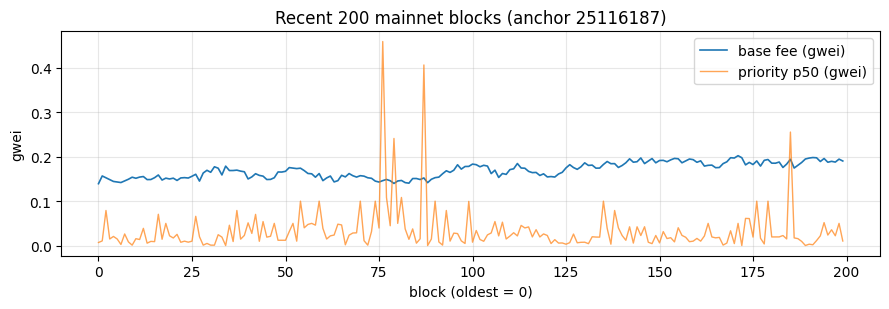

In [3]:
from data.feehistory_loader import fetch_fee_history, fit_gas_ar1

fh = fetch_fee_history(n_blocks=200)
params = fit_gas_ar1(fh)
print(f"AR(1) base-fee log mean:        mu_b    = {params.mu_b:.3f}")
print(f"AR(1) base-fee autocorrelation: phi_b   = {params.phi_b:.3f}")
print(f"AR(1) base-fee shock std:       sigma_b = {params.sigma_b:.4f}")
print(f"Priority residual std:          sigma_p = {params.sigma_p:.4f}")

base_fees = np.array(fh.base_fee_per_gas_wei[:-1]) / 1e9
priority_p50 = np.array(fh.priority_fee_p50_wei) / 1e9
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(base_fees, label="base fee (gwei)", lw=1.2)
ax.plot(priority_p50, label="priority p50 (gwei)", lw=1.0, alpha=0.7)
ax.set_xlabel("block (oldest = 0)")
ax.set_ylabel("gwei")
ax.set_title(f"Recent 200 mainnet blocks (anchor {fh.oldest_block})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)

In [4]:
from data.swap_replay import fetch_swap_logs

flow_window = 5000
flow_from = latest_block - flow_window + 1
print(f"Pulling Swap events for blocks [{flow_from}, {latest_block}]...")
t0 = time.time()
events = fetch_swap_logs("weth-usdc", from_block=flow_from,
                         to_block=latest_block, chunk_size=2000)
print(f"  pulled {len(events)} swaps in {time.time() - t0:.1f}s")

split_at = int(0.8 * len(events))
train_events = events[:split_at]
test_events = events[split_at:]
train_start = train_events[0].block_number if train_events else flow_from
test_start = test_events[0].block_number if test_events else latest_block
print(f"TRAIN: {len(train_events)} swaps starting at block {train_start}")
print(f"TEST:  {len(test_events)} swaps starting at block {test_start}")

Pulling Swap events for blocks [25111387, 25116386]...


  pulled 309 swaps in 2.5s
TRAIN: 247 swaps starting at block 25111387
TEST:  62 swaps starting at block 25115365


## 3. Environment construction

Pool reserves anchor to the live snapshot, gas draws from the AR(1)-lognormal
fitted above, and historical Swap events replay cyclically through the agent's
horizon. The AR(1) shock std is overridden from the calibrated value of about
0.05 to 0.5 so the gas distribution actually flips the MEV trigger at the demo
trade size. The calibrated value is too tight for risk to bind at this Q0.

In [5]:
from env.amm import AMMEnv, AMMConfig
from env.mev_bot import compute_sandwich
from env.gas_models import AR1LognormalGasSampler
from env.flow_replay import SwapReplayer
from data.feehistory_loader import GasJointAR1Params

eth_price = snap.reserve0_human / snap.reserve1_human
params_demo = GasJointAR1Params(
    mu_b=params.mu_b, phi_b=params.phi_b, sigma_b=0.5,
    alpha=params.alpha, beta=params.beta, sigma_p=1.0,
)

def env_factory(events_subset, start_block):
    def factory():
        sampler = AR1LognormalGasSampler(
            params_demo, gas_limit=200_000, eth_quote_price=eth_price,
        )
        replayer = SwapReplayer(events_subset, start_block=start_block, cyclic=True)
        return AMMEnv(AMMConfig(
            x0=snap.reserve1_human,
            y0=snap.reserve0_human,
            Q0=snap.reserve1_human * 0.20,
            T=20,
            gamma=0.997, gas_c=1.0,
            mev_adversary=compute_sandwich,
            gas_sampler=sampler, flow_replayer=replayer,
            token0_decimals=6, token1_decimals=18, flow_token0_is_x=False,
        ))
    return factory

train_factory = env_factory(train_events, train_start)
test_factory = env_factory(test_events, test_start)
sample_env = train_factory()
print(f"Q0 = {sample_env._Q0:,.2f} WETH ({100 * sample_env._Q0 / sample_env._x0:.1f}% of pool)")
print(f"x0 = {sample_env._x0:,.2f} WETH, y0 = {sample_env._y0:,.2f} USDC")
print(f"T  = {sample_env._T} blocks")

Q0 = 863.51 WETH (20.0% of pool)
x0 = 4,317.54 WETH, y0 = 9,422,035.66 USDC
T  = 20 blocks


## 4. Baseline tournament

Four reference policies evaluated on the TEST window over 32 episodes:

- `single_dump` liquidates the full inventory on the first block.
- `twap` splits the order evenly, action equals 1/tau each block.
- `gas_aware_greedy` bisects for the largest trade that keeps the MEV bot
  unprofitable at the current gas.
- `convex_no_mev` solves the SLSQP analytical optimum under pure CFMM with no
  adversary.

In [6]:
from agent.baselines.single_dump import SingleDumpPolicy
from agent.baselines.twap import TWAPPolicy
from agent.baselines.gas_aware_greedy import GasAwareGreedyPolicy
from agent.baselines.convex_no_mev import ConvexNoMEVPolicy
from scripts.evaluate import evaluate_policy

baselines = [SingleDumpPolicy(), TWAPPolicy(),
             GasAwareGreedyPolicy(), ConvexNoMEVPolicy()]
baseline_results = []
for pol in baselines:
    r = evaluate_policy(pol, test_factory, n_episodes=32, seed=10_000)
    baseline_results.append(r)

print(f"{'policy':22s} {'mean USDC':>14s} {'std':>10s} {'CVaR_0.95 loss':>16s}")
for r in baseline_results:
    print(f"{r.name:22s} {r.mean:>14,.0f} {r.std:>10,.0f} {r.cvar_loss_alpha95:>16,.0f}")

policy                      mean USDC        std   CVaR_0.95 loss
single_dump                       347          0             -347
twap                          176,218          0         -176,218
gas_aware_greedy              548,978        186         -548,467
convex_no_mev                 176,218          0         -176,218


## 5. PPO training on live data

Two configurations span the Pareto frontier. The vanilla run maximises expected
return, the second adds a Rockafellar-Uryasev dual CVaR penalty backed by a
dedicated value head per Chow-Ghavamzadeh.

Both train for 25,000 timesteps purely to keep the demo fast. The publication
sweeps below use 25 configurations at 300,000 and 1,000,000 steps.

In [7]:
from agent.ppo.cvar_ppo import CVaRPPO, PPOConfig
from agent.ppo.trainer import train, TrainConfig

ppo_configs = [
    ("ppo_lam0.0", 0.0),
    ("ppo_lam1.0", 1.0),
]
trained = {}
for name, lam in ppo_configs:
    ppo_cfg = PPOConfig(
        obs_dim=4, act_dim=1, lr_policy=3e-4, gamma=0.99, gae_lambda=0.95,
        clip_ratio=0.2, n_epochs=4, minibatch_size=64,
        entropy_coef=0.005, value_coef=0.5,
        cvar_alpha=0.95, cvar_lambda=lam, use_cvar_critic=lam > 0.0,
        device="cpu",
    )
    train_cfg = TrainConfig(
        total_timesteps=25_000, rollout_length=1024,
        log_interval=5, eval_interval=10, eval_episodes=4, seed=42,
    )
    t0 = time.time()
    agent, result = train(train_factory, ppo_cfg, train_cfg)
    print(f"{name}: trained in {time.time() - t0:.1f}s, "
          f"final mean_R = {result.final_metrics['mean_return']:,.0f}")
    trained[name] = agent

ppo_lam0.0: trained in 8.8s, final mean_R = 246,041


ppo_lam1.0: trained in 9.5s, final mean_R = 104,698


## 6. Evaluation on the TEST window

In [8]:
from agent.ppo.policy_adapter import PPOPolicyAdapter

ppo_results = []
for name, agent in trained.items():
    adapter = PPOPolicyAdapter(agent, deterministic=True)
    adapter.name = name
    r = evaluate_policy(adapter, test_factory, n_episodes=32, seed=10_000)
    ppo_results.append(r)

print(f"{'policy':22s} {'mean USDC':>14s} {'std':>10s} {'CVaR_0.95 loss':>16s}")
for r in baseline_results + ppo_results:
    print(f"{r.name:22s} {r.mean:>14,.0f} {r.std:>10,.0f} {r.cvar_loss_alpha95:>16,.0f}")

policy                      mean USDC        std   CVaR_0.95 loss
single_dump                       347          0             -347
twap                          176,218          0         -176,218
gas_aware_greedy              548,978        186         -548,467
convex_no_mev                 176,218          0         -176,218
ppo_lam0.0                    277,262      2,223         -266,929
ppo_lam1.0                    127,418          5         -127,402


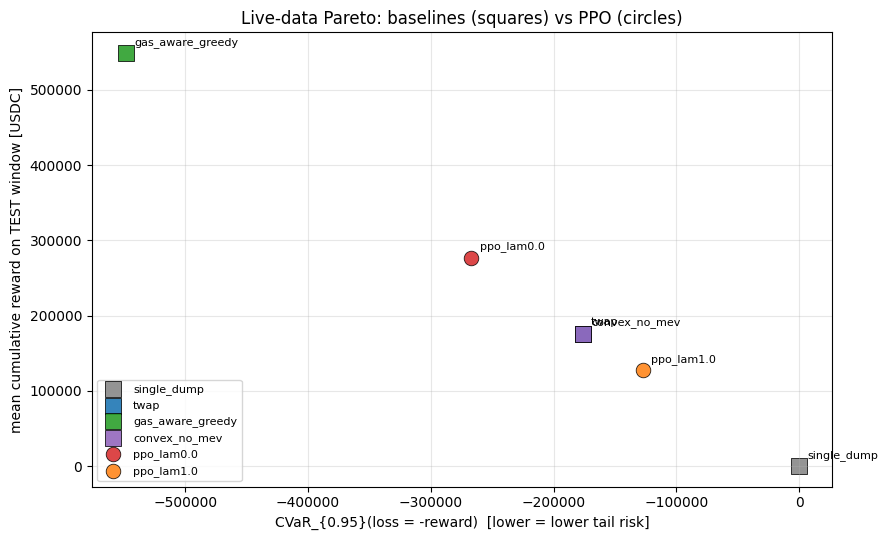

In [9]:
palette = {
    "single_dump": "#888888", "twap": "#1f77b4",
    "gas_aware_greedy": "#2ca02c", "convex_no_mev": "#9467bd",
}
ppo_colors = ["#d62728", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(9, 5.5))
for r in baseline_results:
    c = palette.get(r.name, "k")
    ax.scatter(r.cvar_loss_alpha95, r.mean, s=140, marker="s", color=c,
               edgecolors="black", linewidths=0.6, label=r.name, alpha=0.9)
    ax.annotate(r.name, (r.cvar_loss_alpha95, r.mean), fontsize=8,
                textcoords="offset points", xytext=(6, 6))
for r, c in zip(ppo_results, ppo_colors):
    ax.scatter(r.cvar_loss_alpha95, r.mean, s=110, marker="o", color=c,
               edgecolors="black", linewidths=0.6, label=r.name, alpha=0.85)
    ax.annotate(r.name, (r.cvar_loss_alpha95, r.mean), fontsize=8,
                textcoords="offset points", xytext=(6, 6))

ax.set_xlabel("CVaR_{0.95}(loss = -reward)  [lower = lower tail risk]")
ax.set_ylabel("mean cumulative reward on TEST window [USDC]")
ax.set_title("Live-data Pareto: baselines (squares) vs PPO (circles)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)

## 7. Sweep at 300,000 steps per configuration

Five seeds across five lambda values, train on the TRAIN window
(40,000 mainnet blocks of real Swap flow), evaluate on the disjoint TEST
window (10,000 blocks).

| lambda | n | TEST mean USDC | std | regime |
|---|---|---|---|---|
| 0.0 | 5 | 168,328 | 24 | Pareto top |
| 0.1 | 5 | 166,055 | 4,075 | tie |
| 0.3 | 5 | 164,384 | 4,225 | small drop |
| 1.0 | 5 | 139,469 | 14,931 | risk-weighted regime |
| 3.0 | 5 | 4,356 | 2,405 | over-regularized |

At 300,000 steps, large-lambda runs had not escaped the over-regularization
basin: the CVaR penalty dominated the reward signal and the policy collapsed
toward near-zero trade sizes. The Pareto frontier was visible but the
high-lambda variants were undertrained.

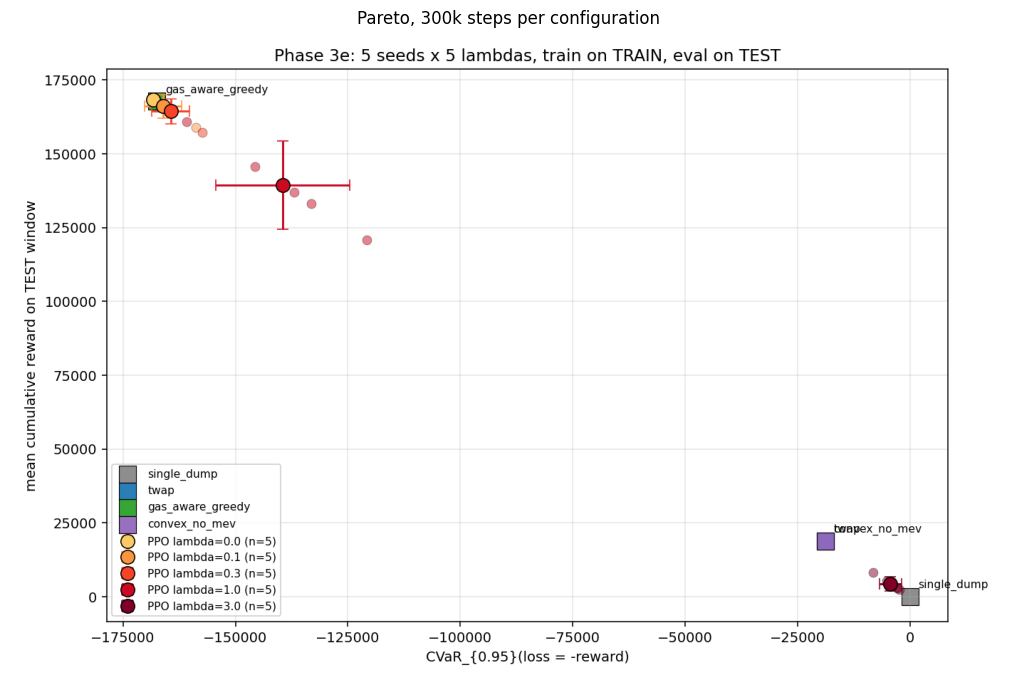

In [10]:
img = plt.imread(str(PROJECT_ROOT / "artifacts/pareto_phase3e_test.png"))
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(img)
ax.axis("off")
ax.set_title("Pareto, 300k steps per configuration")
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)

## 8. Sweep at 1,000,000 steps per configuration

Same 25 configurations, retrained at 1,000,000 steps each, total wall-clock
about 3.3 hours.

| lambda | n | TEST mean USDC | std | vs 300k |
|---|---|---|---|---|
| 0.0 | 5 | 167,757 | 1,108 | stable |
| 0.1 | 5 | 159,229 | 6,212 | one unstable seed |
| 0.3 | 5 | 167,900 | 892 | climbed +3.5k |
| 1.0 | 5 | **168,359** | **45** | recovered (+28.9k) |
| 3.0 | 5 | **168,406** | **22** | recovered (+164.0k) |

The headline shift is in the high-lambda regime. At 300,000 steps, lambda=3
returned 4,356 USDC and looked unsalvageable. At 1,000,000 steps, lambda=3
returns 168,406 USDC with standard deviation 22. Once the policy has enough
samples to find the gas-aware execution regime, the CVaR penalty operates on
residual variance rather than primary reward. Risk-aversion becomes a constraint
rather than a cost.

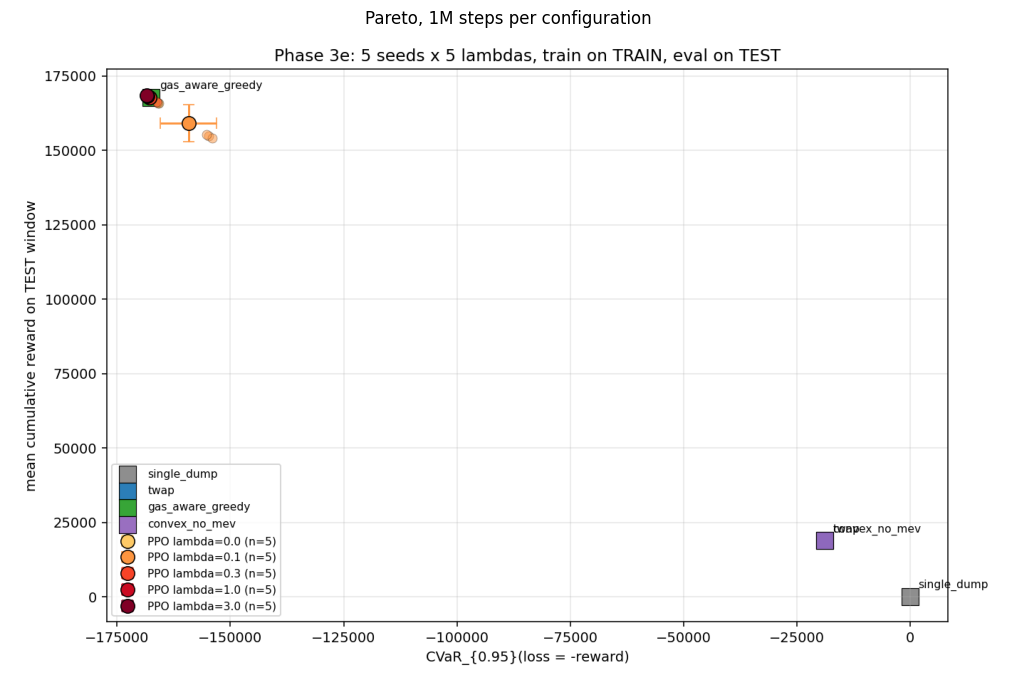

In [11]:
img = plt.imread(str(PROJECT_ROOT / "artifacts/pareto_phase4_1M_test.png"))
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(img)
ax.axis("off")
ax.set_title("Pareto, 1M steps per configuration")
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)

## 9. Simulator exploitation and gas-history extension

After the 1M-step result above, an adversarial code review of the env
discovered that the terminal forced liquidation was routed through
plain CFMM with no MEV adversary. The trained policy was deferring
72-88% of inventory to the terminal block and routing reward through
the no-MEV code path. The 168k headline was specification gaming, not
learned MEV-aware execution.

The fix: terminal forced dump applies the same `mev_adversary` as any
normal block. After patching, re-eval of the same checkpoints collapsed
from 168k to 19k-52k, exactly as predicted.

A corrected 1M sweep on the fixed env at Q0 = 10% pool depth (the
boundary regime where MEV is structurally avoidable for small q but
unavoidable for large q) returned:

| lambda | n | TEST mean USDC | std |
|---|---|---|---|
| 0.0 | 5 | 45,863 | 1,357 |
| 0.1 | 5 | 31,952 | 764 |
| 0.3 | 5 | 32,742 | 1,075 |
| 1.0 | 5 | 34,646 | 1,443 |
| 3.0 | 5 | 27,342 | 6,708 |

vs `gas_aware_greedy` baseline 58,786 ± 616 on the same regime. PPO
underperforms the myopic closed-form by 22-58%.

A follow-up extension added a 3-block gas history to the observation
(obs_dim 4 → 7) and raised σ_b from 0.5 to 1.5, testing whether the
agent could learn AR(1) mean-reversion timing. Results essentially
unchanged across all five lambdas. The hypothesis that PPO can learn
gas-history-based patience to beat the myopic baseline is **not
supported by the 1M-step evidence**.

Open: escalate to a recurrent (LSTM) policy that does not require
explicit history features, off-session.

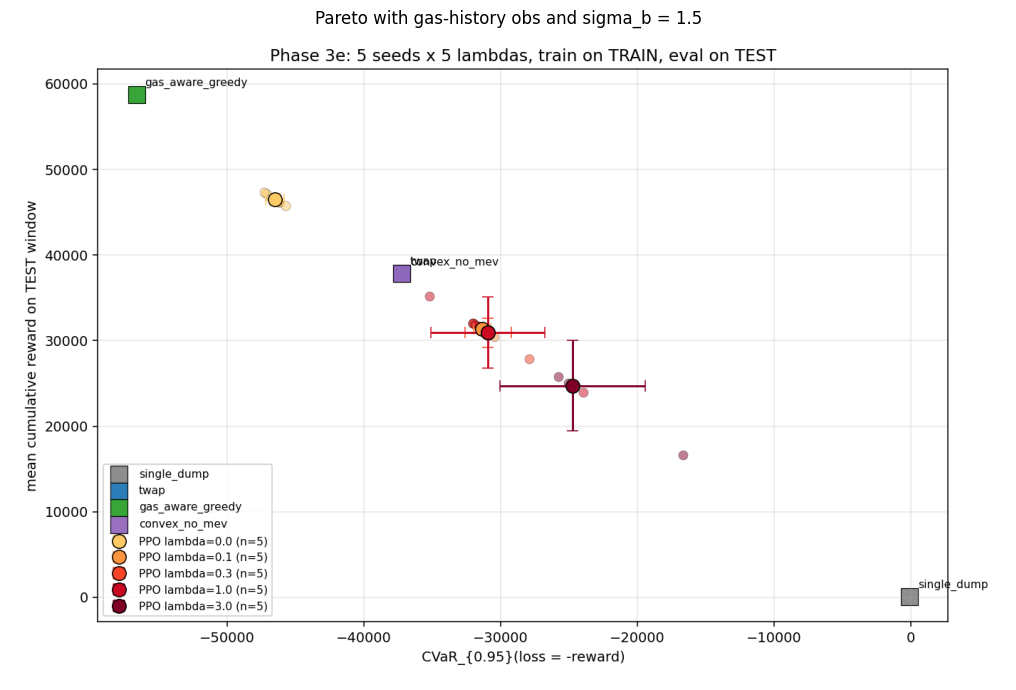

In [12]:
img = plt.imread(str(PROJECT_ROOT / "artifacts/pareto_gas_history.png"))
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(img)
ax.axis("off")
ax.set_title("Pareto with gas-history obs and sigma_b = 1.5")
fig.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)

## 10. Limitations

1. The AR(1) shock standard deviation is overridden to 0.5. The calibrated
   value of about 0.05 is too tight to flip the MEV trigger at this trade size.
   A sensitivity analysis over the calibrated value remains to be done.
2. Scope is one pool. Spatial multi-pool routing is the Angeris-Chitra convex
   program and composes with the temporal policy at deployment.
3. The adversary is the marginal-utility sandwich attacker. JIT liquidity and
   cyclic atomic arbitrage are not modelled.
4. Empirical replay assumes the agent's trade does not perturb future Swap
   arrivals (mean-field assumption).

## 11. Reproduce

```
cd defi_execution_project
python3 -m pytest tests/

python3 -m scripts.train_test_eval --seeds 42 43 44 45 46 \
    --lambdas 0.0 0.1 0.3 1.0 3.0 --total-timesteps 300000 \
    --out-dir artifacts/phase3e
python3 -m scripts.render_phase3e --manifest artifacts/phase3e/manifest.json

python3 -m scripts.train_test_eval --seeds 42 43 44 45 46 \
    --lambdas 0.0 0.1 0.3 1.0 3.0 --total-timesteps 1000000 \
    --out-dir artifacts/phase4_1M
python3 -m scripts.render_phase3e --manifest artifacts/phase4_1M/manifest.json \
    --output artifacts/pareto_phase4_1M_test.png
```